Model considering offered rate, fico score and requested amount to predict whether or not the loan is being accepted by the customer. The model shows a satisfactory performance, even though the effect of the price on the decision seems to be very low. As seen also in the EDA notebook the requested amount seems to be the variable with the largest explanatory power. Here as well the convergence is not perfect

In [241]:
import pymc as pm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import arviz as az
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, auc, roc_curve

In [242]:
df = pd.read_excel("data/data.xlsx")
#Start with only one Tier
df = df[df["Tier"]==2]
df[["Rate", "FICO", "Amount"]] = df[["Rate", "FICO", "Amount"]].apply(lambda x: (x-x.mean())/x.std(), axis=0)
print(f"{df['Outcome'].mean()*100:.2f} % of the loans in the data set have been accepted")
prices_train, prices_test, accepted_train, accepted_test, FICO_scores_train, FICO_scores_test, requested_amount_train, requested_amount_test = train_test_split(df["Rate"].values, df["Outcome"].values, df["FICO"].values, df["Amount"].values,
                                                                            train_size=0.8, shuffle=True, random_state=1)
df.head()

20.40 % of the loans in the data set have been accepted


,N,Approval Date,Tier,FICO,Term,Amount,Loan Type,Previous Rate,Competition rate,Cost of Funds,Partner,Rate,Outcome
0,1,2005-04-17,2,-0.547327,48,0.141202,R,0.0399,0.0499,0.011,2,-0.230257,0
1,2,2005-04-17,2,0.572131,72,0.914875,N,0.0000,0.0479,0.011,2,-1.237988,0
7,8,2005-04-17,2,1.033085,60,-0.305163,R,0.0599,0.0499,0.011,2,-2.480855,0
11,12,2005-04-17,2,1.033085,60,0.004671,N,0.0000,0.0399,0.011,3,-1.573898,0
14,15,2005-04-17,2,1.164785,48,0.082402,U,0.0000,0.0455,0.011,1,-1.405943,0


Text(0.5, 1.0, 'Observed Acceptance vs offered rate')

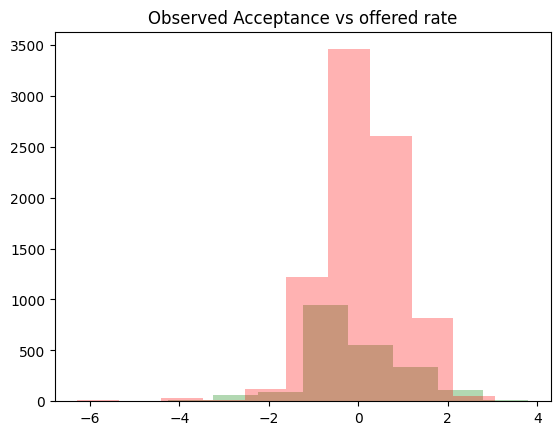

In [243]:
# Show data
plt.hist(df[df["Outcome"]==1]["Rate"], alpha=0.3, color="green")
plt.hist(df[df["Outcome"]==0]["Rate"], alpha=0.3, color="red")
plt.title("Observed Acceptance vs offered rate")

In [244]:
#Start considering price as only factor
base_model = pm.Model()

with base_model:
    #Data
    offered_rates = pm.Data("offered_rate", prices_train)
    FICO_scores = pm.Data("FICO_score", FICO_scores_train)
    requested_amount = pm.Data("requested_amount", requested_amount_train)
    y = pm.Data("y", accepted_train)

    # Priors for coefficients
    beta_0 = pm.Normal("beta_0", mu=0, sigma=1)
    beta_1 = pm.Normal("beta_1", mu=0, sigma=1)
    beta_2 = pm.Normal("beta_2", mu=0, sigma=1)
    beta_3 = pm.Normal("beta_3", mu=0, sigma=1)

    # Linear model
    logit_p = beta_0 + beta_1*offered_rates + beta_2*FICO_scores + beta_3*requested_amount #+ epsilon

    # Likelihood
    p = pm.Deterministic('acceptance_p', pm.math.sigmoid(logit_p))
    y_obs = pm.Bernoulli('y_obs', p=p, observed=y)

In [245]:
#Check the prior distribution
with base_model:
    prior_data = pm.sample_prior_predictive(draws=50, random_seed=1)


Sampling: [beta_0, beta_1, beta_2, beta_3, y_obs]


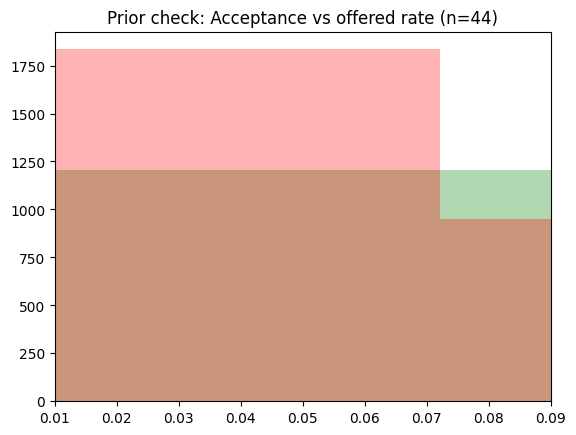

In [246]:
random_idx = np.random.randint(50)
df_prior = pd.DataFrame({"Rate":prices_train, "Outcome": prior_data["prior_predictive"]["y_obs"][0,random_idx,:]})
plt.hist(df_prior[df_prior["Outcome"]==1]["Rate"], alpha=0.3, color="green")
plt.hist(df_prior[df_prior["Outcome"]==0]["Rate"], alpha=0.3, color="red")
plt.xticks([i*0.01 for i in range(10)])
plt.xlim(0.01,0.09)
plt.title(f"Prior check: Acceptance vs offered rate (n={random_idx})")
plt.show()

In [247]:
#Faster sampler -- need to install jax and blackjax. Otherwise use slow sampler
trace = pm.sample(draws=5000, tune=1000, nuts_sampler="blackjax", cores=4, model=base_model)

#Slow Sampler
#with base_model:
#    trace = pm.sample(2000)

Running window adaptation


<Axes: >

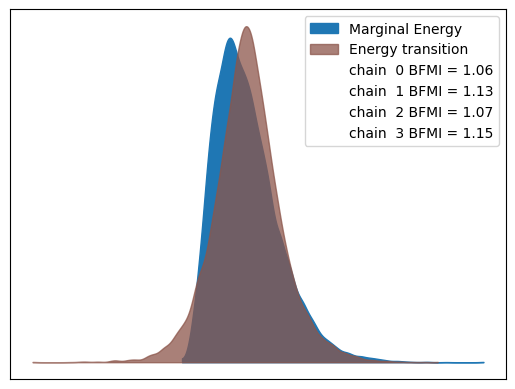

In [248]:
#Check convergence - energy plot
pm.plot_energy(trace)

array([[<Axes: title={'center': 'beta_0'}>,
        <Axes: title={'center': 'beta_0'}>],
       [<Axes: title={'center': 'beta_1'}>,
        <Axes: title={'center': 'beta_1'}>],
       [<Axes: title={'center': 'beta_2'}>,
        <Axes: title={'center': 'beta_2'}>],
       [<Axes: title={'center': 'beta_3'}>,
        <Axes: title={'center': 'beta_3'}>]], dtype=object)

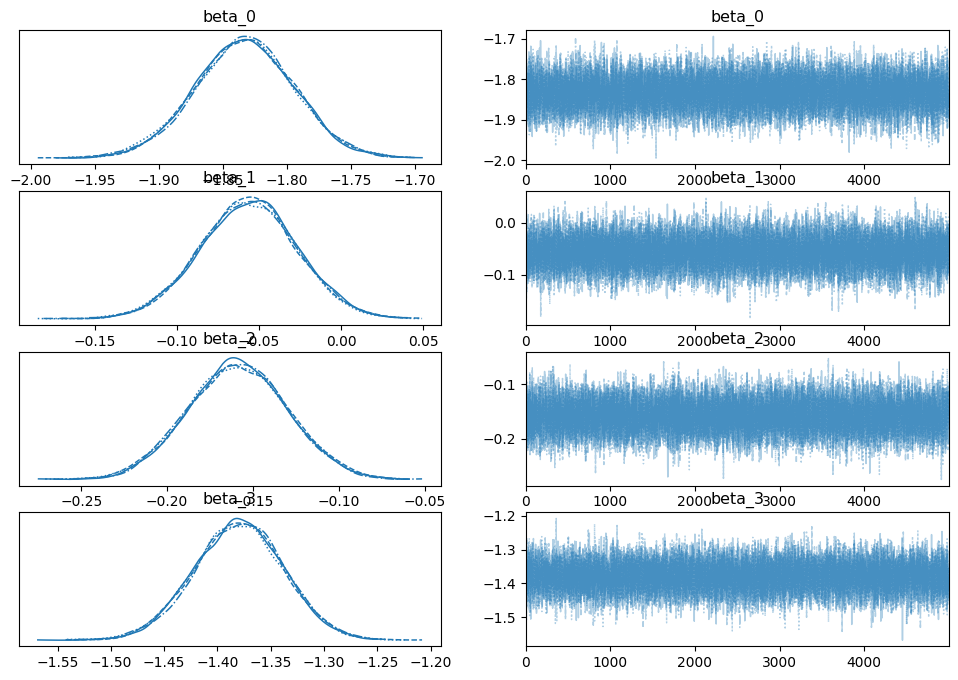

In [249]:
#check convergence - plot trace
az.plot_trace(trace, var_names=["beta_0", "beta_1", "beta_2", "beta_3"])

In [250]:
az.summary(trace, var_names=["beta_0", "beta_1", "beta_2", "beta_3"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,-1.833,0.039,-1.909,-1.763,0.0,0.0,15535.0,13661.0,1.0
beta_1,-0.057,0.029,-0.114,-0.003,0.0,0.0,19014.0,14358.0,1.0
beta_2,-0.159,0.029,-0.213,-0.105,0.0,0.0,18870.0,13917.0,1.0
beta_3,-1.380,0.042,-1.458,-1.301,0.0,0.0,15296.0,14879.0,1.0


array([<Axes: title={'center': 'beta_0'}>,
       <Axes: title={'center': 'beta_1'}>,
       <Axes: title={'center': 'beta_2'}>,
       <Axes: title={'center': 'beta_3'}>], dtype=object)

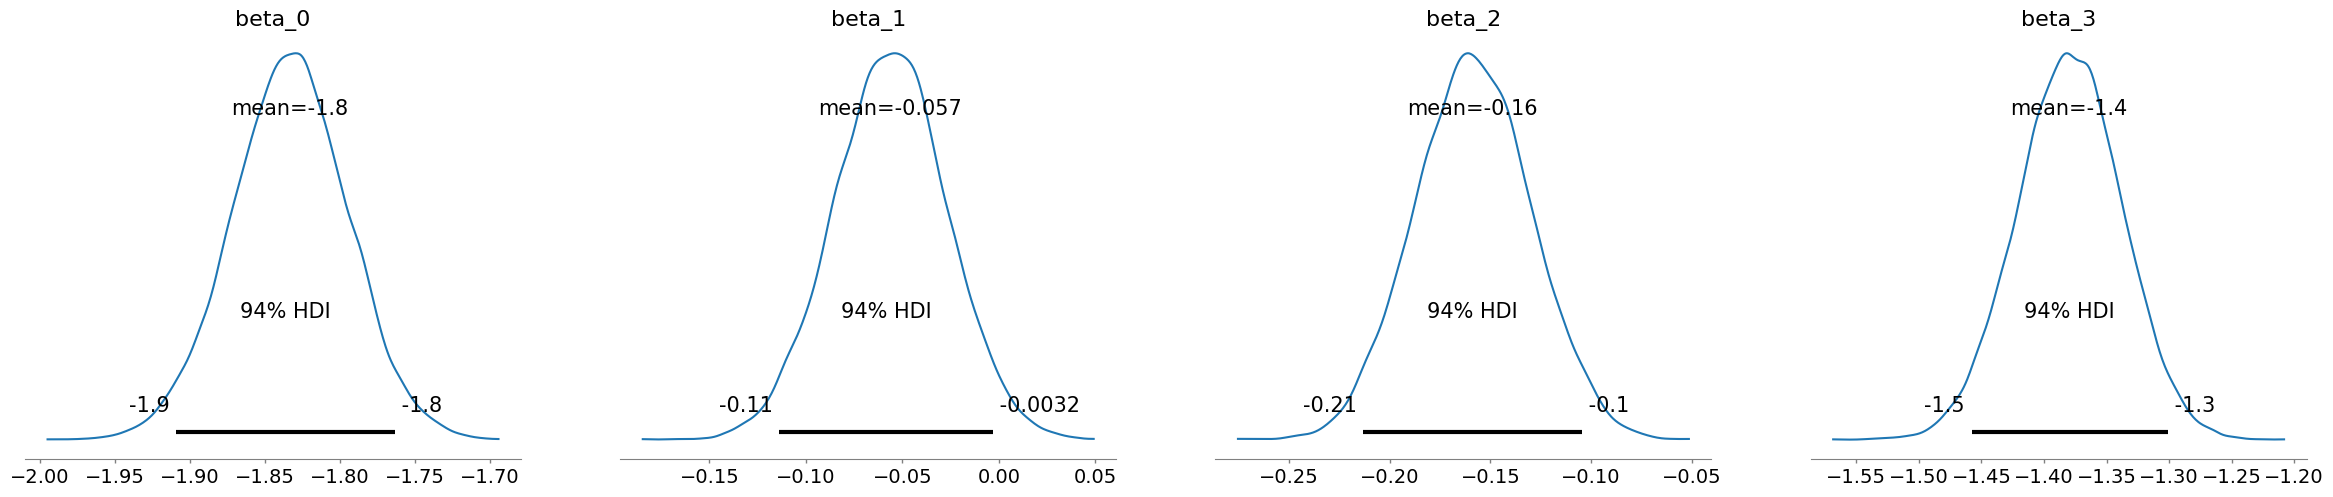

In [251]:
az.plot_posterior(trace, var_names=["beta_0", "beta_1", "beta_2", "beta_3"])
#influence of price (beta_1) seems to be very little if any

Sampling: [y_obs]


/home/eguzzi/.local/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

(array([686., 416., 280., 210., 187., 129.,  93.,  77.,  11.,   3.]),
 array([5.00000e-05, 8.19550e-02, 1.63860e-01, 2.45765e-01, 3.27670e-01,
        4.09575e-01, 4.91480e-01, 5.73385e-01, 6.55290e-01, 7.37195e-01,
        8.19100e-01]),
 <BarContainer object of 10 artists>)

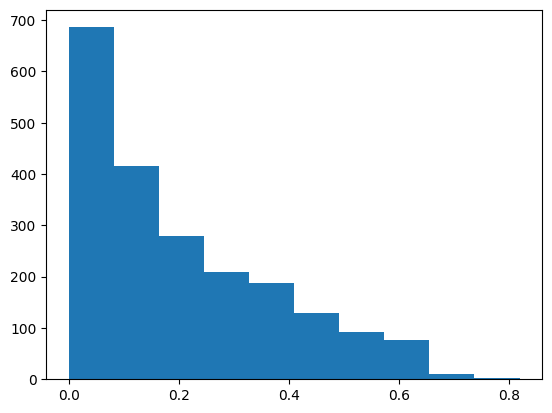

In [252]:
#Test oos predictions
with base_model:
    pm.set_data({"offered_rate":prices_test, "FICO_score":FICO_scores_test, "requested_amount": requested_amount_test, "y": accepted_test})
    extended_trace = pm.sample_posterior_predictive(trace, progressbar=True, predictions=True)
    
predicted_probabilities = extended_trace["predictions"]["y_obs"].mean(dim=["chain", "draw"])
plt.hist(predicted_probabilities)

[Text(0.5, 1.0, 'ROC')]

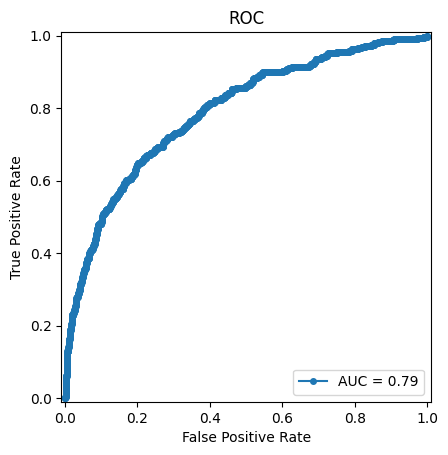

In [253]:
fpr, tpr, thresholds = roc_curve(y_true=accepted_test, y_score=predicted_probabilities, pos_label=1, drop_intermediate=False)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display = roc_display.plot(ax=ax, marker="o", markersize=4)
ax.set(title="ROC")
#ok performance